In [49]:
# Step 1: Install stable, compatible versions
!pip install -q \
langchain==0.2.14 \
langchain-community==0.2.12 \
langchain-huggingface==0.0.3 \
langchain-chroma==0.1.2 \
chromadb==0.5.3 \
sentence-transformers \
transformers \
requests==2.32.4

In [50]:
from google.colab import userdata
import os

# pulling HF token from colab secrets
os.environ['HUGGINGFACEHUB_API_TOKEN'] = userdata.get('HuggingFace_API')

In [51]:
import os
os.environ["USER_AGENT"] = "Mozilla/5.0"

from langchain_community.document_loaders import WebBaseLoader

links = [
    # Getting Started
    "https://docs.flutter.dev/get-started/install",
    "https://docs.flutter.dev/get-started/codelab",

    # UI Core
    "https://docs.flutter.dev/ui",
    "https://docs.flutter.dev/ui/widgets",
    "https://docs.flutter.dev/ui/layout",
    "https://docs.flutter.dev/ui/animations",

    # Layout & Design
    "https://docs.flutter.dev/development/ui/layout",
    "https://docs.flutter.dev/development/ui/layout/responsive",
    "https://docs.flutter.dev/development/ui/advanced",

    # Cookbook
    "https://docs.flutter.dev/cookbook",
    "https://docs.flutter.dev/cookbook/navigation/navigation-basics",
    "https://docs.flutter.dev/cookbook/networking/fetch-data",
    "https://docs.flutter.dev/cookbook/forms/validation",
    "https://docs.flutter.dev/cookbook/design/snackbars",
    "https://docs.flutter.dev/cookbook/animation/opacity-animation",

    # Navigation & Routing
    "https://docs.flutter.dev/development/ui/navigation",
    "https://docs.flutter.dev/development/ui/navigation/declarative",

    # Data & Backend
    "https://docs.flutter.dev/data-and-backend/state-mgmt/intro",
    "https://docs.flutter.dev/data-and-backend/json",
    "https://docs.flutter.dev/development/data-and-backend/networking",
    "https://docs.flutter.dev/development/data-and-backend/database",
    "https://docs.flutter.dev/development/data-and-backend/firebase",

    # State Management Deep
    "https://docs.flutter.dev/data-and-backend/state-mgmt/simple",
    "https://docs.flutter.dev/data-and-backend/state-mgmt/options",

    # DevTools & Debugging
    "https://docs.flutter.dev/development/tools/devtools/overview",
    "https://docs.flutter.dev/development/tools/devtools/performance",
    "https://docs.flutter.dev/development/tools/devtools/memory",
    "https://docs.flutter.dev/development/tools/hot-reload",
    "https://docs.flutter.dev/testing",
    "https://docs.flutter.dev/testing/debugging",

    # Performance
    "https://docs.flutter.dev/perf/best-practices",
    "https://docs.flutter.dev/perf/ui-performance",
    "https://docs.flutter.dev/perf/rendering",
    "https://docs.flutter.dev/perf/shader",

    # Deployment
    "https://docs.flutter.dev/deployment/android",
    "https://docs.flutter.dev/deployment/ios",
    "https://docs.flutter.dev/deployment/web",

    # Platform Integration
    "https://docs.flutter.dev/development/platform-integration",
    "https://docs.flutter.dev/development/platform-integration/platform-channels",

    # Packages & Plugins
    "https://docs.flutter.dev/development/packages-and-plugins",
    "https://docs.flutter.dev/development/packages-and-plugins/using-packages",

    # Architecture & Internals
    "https://docs.flutter.dev/resources/architectural-overview",
    "https://docs.flutter.dev/resources/inside-flutter",

    # Accessibility & Internationalization
    "https://docs.flutter.dev/development/accessibility-and-localization/accessibility",
    "https://docs.flutter.dev/development/accessibility-and-localization/internationalization",

    # Tools & Misc
    "https://docs.flutter.dev/development/tools/formatting",
    "https://docs.flutter.dev/development/tools/sdk/release-notes",
]

loader = WebBaseLoader(web_paths=links)
docs = loader.load()

print(f"Loaded {len(docs)} pages")

Loaded 47 pages


In [52]:
import re
from langchain_core.documents import Document

# raw scraped text has tons of junk — cleaning it up before chunking
clean_docs = []

for doc in docs:
    text = doc.page_content
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"\t+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    clean_docs.append(Document(page_content=text, metadata=doc.metadata))

print(f"Cleaned {len(clean_docs)} docs")

Cleaned 47 docs


In [53]:
eval_data = [
    {
        "question": "Explain how Flutter handles navigation between screens",
        "answer": "Navigator push pop routes"
    },
    {
        "question": "How does Flutter perform HTTP network requests?",
        "answer": "http package fetch data async"
    },
    {
        "question": "What is the role of widgets in Flutter UI?",
        "answer": "widgets build user interface tree"
    },
    {
        "question": "How are Flutter apps tested?",
        "answer": "unit test widget test integration test"
    },
    {
        "question": "What tools are used to debug Flutter apps?",
        "answer": "devtools debugging performance"
    }
]

In [54]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [55]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from langchain_chroma import Chroma

chunk_sizes = [250, 500, 1000, 1500, 2000]
results = {}

for chunk_size in chunk_sizes:
    print(f"\nRunning experiment for chunk size: {chunk_size}")

    # Step 1: Chunking
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size * 0.2),
        separators=["\n\n", "\n", ".", " ", ""]
    )

    splits = splitter.split_documents(clean_docs)
    print(f"Total chunks: {len(splits)}")

    # Step 2: Vector Store
    vectorstore = Chroma.from_documents(
        documents=splits,
        embedding=embedding
    )

    retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

    # Step 3: Evaluation

    correct = 0
    total_score = 0

    for item in eval_data:
        query = item["question"]
        ground_truth = item["answer"]

        retrieved_docs = retriever.invoke(query)
        retrieved_text = " ".join([doc.page_content for doc in retrieved_docs])

        # Convert to embeddings
        gt_embedding = embedding.embed_query(ground_truth)
        retrieved_embedding = embedding.embed_query(retrieved_text)

        # Compute similarity
        similarity = cosine_similarity(
            [gt_embedding], [retrieved_embedding]
        )[0][0]

        print(f"\nQuery: {query}")
        print(f"Similarity Score: {similarity:.4f}")

        total_score += similarity

    # Average similarity instead of binary accuracy
    accuracy = total_score / len(eval_data)
    results[chunk_size] = accuracy

    print(f"Avg Similarity Score: {accuracy:.4f}")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given



Running experiment for chunk size: 250
Total chunks: 5309


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given



Query: Explain how Flutter handles navigation between screens
Similarity Score: 0.3275

Query: How does Flutter perform HTTP network requests?
Similarity Score: 0.3116

Query: What is the role of widgets in Flutter UI?
Similarity Score: 0.4051

Query: How are Flutter apps tested?
Similarity Score: 0.1772

Query: What tools are used to debug Flutter apps?
Similarity Score: 0.2167
Avg Similarity Score: 0.2876

Running experiment for chunk size: 500
Total chunks: 2548


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given



Query: Explain how Flutter handles navigation between screens
Similarity Score: 0.3275

Query: How does Flutter perform HTTP network requests?
Similarity Score: 0.3116

Query: What is the role of widgets in Flutter UI?
Similarity Score: 0.4051

Query: How are Flutter apps tested?
Similarity Score: 0.3092

Query: What tools are used to debug Flutter apps?
Similarity Score: 0.3365
Avg Similarity Score: 0.3380

Running experiment for chunk size: 1000
Total chunks: 1258


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given



Query: Explain how Flutter handles navigation between screens
Similarity Score: 0.3275

Query: How does Flutter perform HTTP network requests?
Similarity Score: 0.3116

Query: What is the role of widgets in Flutter UI?
Similarity Score: 0.4051

Query: How are Flutter apps tested?
Similarity Score: 0.1772

Query: What tools are used to debug Flutter apps?
Similarity Score: 0.3365
Avg Similarity Score: 0.3116

Running experiment for chunk size: 1500
Total chunks: 873


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given



Query: Explain how Flutter handles navigation between screens
Similarity Score: 0.3275

Query: How does Flutter perform HTTP network requests?
Similarity Score: 0.3116

Query: What is the role of widgets in Flutter UI?
Similarity Score: 0.4051

Query: How are Flutter apps tested?
Similarity Score: 0.1772

Query: What tools are used to debug Flutter apps?
Similarity Score: 0.3365
Avg Similarity Score: 0.3116

Running experiment for chunk size: 2000
Total chunks: 655

Query: Explain how Flutter handles navigation between screens
Similarity Score: 0.3275

Query: How does Flutter perform HTTP network requests?
Similarity Score: 0.3116

Query: What is the role of widgets in Flutter UI?
Similarity Score: 0.4051

Query: How are Flutter apps tested?
Similarity Score: 0.3310

Query: What tools are used to debug Flutter apps?
Similarity Score: 0.3365
Avg Similarity Score: 0.3424


In [56]:
print("\nFinal Results:")
for size, acc in results.items():
    print(f"Chunk Size {size}: Accuracy {acc:.2f}")


Final Results:
Chunk Size 250: Accuracy 0.29
Chunk Size 500: Accuracy 0.34
Chunk Size 1000: Accuracy 0.31
Chunk Size 1500: Accuracy 0.31
Chunk Size 2000: Accuracy 0.34


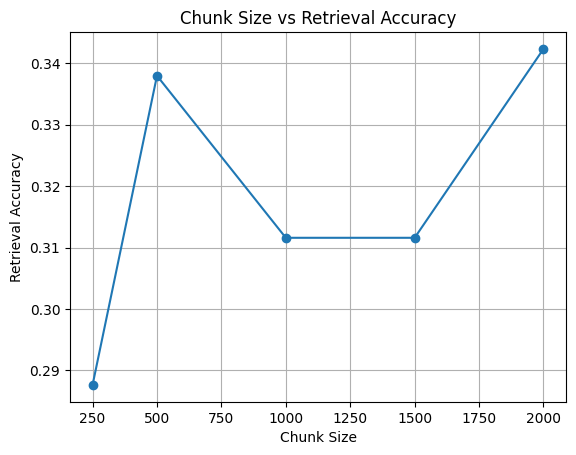

In [57]:
import matplotlib.pyplot as plt

x = list(results.keys())
y = list(results.values())

plt.plot(x, y, marker='o')
plt.xlabel("Chunk Size")
plt.ylabel("Retrieval Accuracy")
plt.title("Chunk Size vs Retrieval Accuracy")
plt.grid()
plt.show()